In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Adjust the file path if your CSV is located elsewhere in your Google Drive
file_path = '/content/drive/MyDrive/ASALA/ASALA_Raw.csv'

try:
    df = pd.read_csv(file_path)
    print(f'Successfully loaded data from {file_path}')
    display(df.head())
except FileNotFoundError:
    print(f'Error: The file {file_path} was not found. Please check the path and filename.')
except Exception as e:
    print(f'An error occurred: {e}')

Successfully loaded data from /content/drive/MyDrive/ASALA/ASALA_Raw.csv


,Text,Dialect
0,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...,GLF
1,من الخير نفسه 💛,GLF
2,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...,GLF
3,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...,GLF
4,#الاتحاد_النصر لاتحسبونا نسينا يالطواقي ولانبي...,GLF


In [ ]:
print(len(df))

3366554


In [ ]:
import pandas as pd
import re
import unicodedata

def normalize_text(text):
    if pd.isna(text):
        return ""

    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("ـ", "")  # remove tatweel

    # Remove Arabic diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["normalized_text"] = df["Text"].apply(normalize_text)

In [ ]:
valid = df[df["normalized_text"] != ""]

duplicate_mask = valid.duplicated(
    subset=["normalized_text"],
    keep=False
)

duplicate_rows = valid[duplicate_mask]

print("Total records:", len(df))
print("Records involved in duplicate groups:", len(duplicate_rows))
print(
    "Unique duplicated texts:",
    duplicate_rows["normalized_text"].nunique()
)

Total records: 3366554
Records involved in duplicate groups: 1016941
Unique duplicated texts: 456327


In [ ]:
cross_dialect = (
    valid.groupby("normalized_text")["Dialect"]
         .nunique()
)

cross_dialect = cross_dialect[cross_dialect > 1]

print(
    "Texts appearing under multiple dialect labels:",
    len(cross_dialect)
)

Texts appearing under multiple dialect labels: 17523


In [ ]:
cross_dialect_records = valid[
    valid["normalized_text"].isin(cross_dialect.index)
][["Dialect", "Text", "normalized_text"]]

print(cross_dialect_records.head(30))

      Dialect                                               Text  \
462       GLF                سبحان الله العظيم سبحان الله وبحمده   
543       GLF                                         صح لسانك 👌   
2838      GLF  ربي جمل صبآحنآ بذكرك وعفوك وتوفيقك وبركآتك ورض...   
3029      GLF                                      جزاك الله خير   
3130      GLF                             حسبنا الله ونعم الوكيل   
7236      GLF                   هذه الشنطة شوهدت في مترو برلين 😉   
7765      GLF                             حسبي الله ونعمه الوكيل   
7957      GLF                           اللهم آمين يارب العالمين   
8053      GLF                     لا تخرج قبل ان تقول سبحان الله   
8758      GLF                                      صباح الخير :)   
9090      GLF                                      جزاك الله خير   
11557     GLF                                      جزاك الله خير   
14922     GLF                        انتم السابقون ونحن اللاحقون   
14969     GLF  ربي جمل صبآحنآ بذكرك وعفوك وتوفيق

In [ ]:
cross_records = df[
    df["normalized_text"].isin(cross_dialect.index)
].copy()

cross_records["word_count"] = (
    cross_records["normalized_text"]
    .str.split()
    .str.len()
)

print(cross_records["word_count"].describe())

print(
    cross_records["word_count"]
    .value_counts()
    .sort_index()
    .head(30)
)

count    53516.000000
mean         5.599428
std          8.129513
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max        542.000000
Name: word_count, dtype: float64
word_count
1     16208
2      8055
3      4991
4      3715
5      2859
6      2305
7      2021
8      1850
9      1615
10     1333
11     1177
12     1091
13      884
14      801
15      691
16      569
17      490
18      428
19      331
20      384
21      258
22      208
23      159
24      118
25      106
26       96
27       91
28       58
29       52
30       38
Name: count, dtype: int64


In [ ]:
import pandas as pd

dialect_count = (
    df.groupby("normalized_text")["Dialect"]
      .nunique()
)

cross_texts = dialect_count[dialect_count > 1].index

cross_df = df[
    df["normalized_text"].isin(cross_texts)
].copy()

# Word count
cross_df["word_count"] = (
    cross_df["normalized_text"]
    .str.split()
    .str.len()
)

print("Unique texts appearing under multiple dialects:",
      len(cross_texts))

print("Records involved:",
      len(cross_df))



cross_summary = (
    cross_df
    .groupby("normalized_text")
    .agg(
        word_count=("word_count", "first"),
        number_of_records=("normalized_text", "size"),
        number_of_dialects=("Dialect", "nunique"),
        dialects=(
            "Dialect",
            lambda x: tuple(sorted(set(x)))
        )
    )
    .reset_index()
)



combination_counts = (
    cross_summary["dialects"]
    .value_counts()
    .reset_index()
)

combination_counts.columns = [
    "dialect_combination",
    "unique_texts"
]

print("\nMost frequent dialect combinations:")
print(combination_counts.head(30).to_string(index=False))




aeb_mgh = cross_summary[
    cross_summary["dialects"] == ("AEB", "MGH")
].copy()

print("\n==============================")
print("AEB <-> MGH")
print("==============================")

print("Unique overlapping texts:", len(aeb_mgh))
print(aeb_mgh["word_count"].describe())

for threshold in [1, 5, 10, 20, 30, 50, 100]:
    print(
        f">= {threshold} words:",
        (aeb_mgh["word_count"] >= threshold).sum()
    )



jrd_lev = cross_summary[
    cross_summary["dialects"] == ("JRD", "LEV")
].copy()

print("\n==============================")
print("JRD <-> LEV")
print("==============================")

print("Unique overlapping texts:", len(jrd_lev))
print(jrd_lev["word_count"].describe())

for threshold in [1, 5, 10, 20, 30, 50, 100]:
    print(
        f">= {threshold} words:",
        (jrd_lev["word_count"] >= threshold).sum()
    )


compatible_pairs = {
    ("AEB", "MGH"),
    ("JRD", "LEV")
}

cross_summary["compatible_pair"] = (
    cross_summary["dialects"]
    .apply(lambda x: x in compatible_pairs)
)

compatible = cross_summary[
    cross_summary["compatible_pair"]
].copy()

other_overlap = cross_summary[
    ~cross_summary["compatible_pair"]
].copy()



print("\n==============================")
print("SUMMARY")
print("==============================")

print(
    "Total cross-dialect unique texts:",
    len(cross_summary)
)

print(
    "AEB-MGH / JRD-LEV:",
    len(compatible)
)

print(
    "Other dialect combinations:",
    len(other_overlap)
)

if len(cross_summary) > 0:
    print(
        "AEB-MGH/JRD-LEV percentage:",
        round(
            len(compatible) / len(cross_summary) * 100,
            2
        ),
        "%"
    )



suspicious_long = other_overlap[
    other_overlap["word_count"] >= 20
].copy()

suspicious_long = suspicious_long.sort_values(
    ["word_count", "number_of_records"],
    ascending=False
)

print("\n==============================")
print("LONG OTHER-DIALECT OVERLAPS")
print("==============================")

print(
    "Unique texts >=20 words:",
    len(suspicious_long)
)

for threshold in [20, 30, 50, 100]:
    print(
        f">= {threshold} words:",
        (
            suspicious_long["word_count"]
            >= threshold
        ).sum()
    )


print("\nLongest potentially suspicious cases:")

print(
    suspicious_long[
        [
            "word_count",
            "number_of_records",
            "number_of_dialects",
            "dialects",
            "normalized_text"
        ]
    ]
    .head(30)
    .to_string(index=False)
)


cross_summary.to_csv(
    "ASALA_Raw_all_cross_dialect_overlap.csv",
    index=False,
    encoding="utf-8-sig"
)

aeb_mgh.to_csv(
    "ASALA_Raw_AEB_MGH_overlap.csv",
    index=False,
    encoding="utf-8-sig"
)

jrd_lev.to_csv(
    "ASALA_Raw_JRD_LEV_overlap.csv",
    index=False,
    encoding="utf-8-sig"
)

suspicious_long.to_csv(
    "ASALA_Raw_suspicious_long_cross_dialect.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nAnalysis complete. CSV files saved.")

Unique texts appearing under multiple dialects: 17523
Records involved: 53516

Most frequent dialect combinations:
dialect_combination  unique_texts
         (AEB, MGH)         10515
         (JRD, LEV)          5385
         (LEV, MGH)           191
         (EGY, JRD)           185
         (EGY, GLF)           127
         (EGY, LEV)           115
         (AEB, EGY)            76
         (EGY, MSA)            70
         (JRD, MGH)            67
         (GLF, JRD)            66
         (AEB, JRD)            50
         (GLF, LEV)            37
         (EGY, MGH)            33
         (JRD, MSA)            31
         (AEB, GLF)            23
    (EGY, GLF, JRD)            22
     (EGY, general)            21
    (AEB, JRD, MGH)            21
         (AEB, LEV)            18
    (EGY, JRD, LEV)            18
    (AEB, MGH, MSA)            17
    (AEB, EGY, MGH)            17
    (EGY, GLF, LEV)            16
     (LEV, general)            16
     (JRD, general)            13
 

# ============================================================
# ASALA-RAW CONTROLLED DEDUPLICATION
#
# Policy:
# 1. Remove repeated normalized text WITHIN the same dialect.
# 2. Keep one occurrence per dialect.
# 3. Preserve texts occurring across different dialect labels.
# 4. Do not automatically collapse cross-dialect overlaps.
# 5. Keep audit files for complete transparency.
# ============================================================

In [ ]:

import pandas as pd

print("=" * 70)
print("ASALA-RAW CONTROLLED DEDUPLICATION")
print("=" * 70)



required_columns = [
    "Text",
    "Dialect",
    "normalized_text"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


original_size = len(df)

print(f"\nOriginal records: {original_size:,}")

print("\nDialect distribution BEFORE deduplication:")
print(
    df["Dialect"]
    .value_counts(dropna=False)
    .sort_index()
)

empty_mask = (
    df["normalized_text"].isna()
    | df["normalized_text"].eq("")
)

empty_records = df[empty_mask].copy()

print(
    f"\nEmpty normalized-text records: "
    f"{len(empty_records):,}"
)


valid_df = df[~empty_mask].copy()

print(
    f"Valid textual records used for deduplication: "
    f"{len(valid_df):,}"
)


within_dialect_duplicate_mask = (
    valid_df.duplicated(
        subset=[
            "normalized_text",
            "Dialect"
        ],
        keep="first"
    )
)

within_dialect_duplicates = (
    valid_df[
        within_dialect_duplicate_mask
    ].copy()
)

print(
    "\nRedundant within-dialect records identified:",
    f"{len(within_dialect_duplicates):,}"
)


valid_dedup = (
    valid_df
    .drop_duplicates(
        subset=[
            "normalized_text",
            "Dialect"
        ],
        keep="first"
    )
    .copy()
)


df_dedup = pd.concat(
    [
        valid_dedup,
        empty_records
    ],
    axis=0
)

df_dedup = (
    df_dedup
    .sort_index()
    .reset_index(drop=True)
)



valid_after = df_dedup[
    df_dedup["normalized_text"].notna()
    & df_dedup["normalized_text"].ne("")
].copy()

dialect_count = (
    valid_after
    .groupby("normalized_text")["Dialect"]
    .nunique()
)

cross_texts = (
    dialect_count[
        dialect_count > 1
    ]
    .index
)

cross_df = (
    valid_after[
        valid_after["normalized_text"]
        .isin(cross_texts)
    ]
    .copy()
)

cross_df["word_count"] = (
    cross_df["normalized_text"]
    .str.split()
    .str.len()
)


cross_summary = (
    cross_df
    .groupby("normalized_text")
    .agg(
        word_count=(
            "word_count",
            "first"
        ),

        number_of_records=(
            "normalized_text",
            "size"
        ),

        number_of_dialects=(
            "Dialect",
            "nunique"
        ),

        dialects=(
            "Dialect",
            lambda x: tuple(
                sorted(set(x))
            )
        )
    )
    .reset_index()
)


compatible_pairs = {
    ("AEB", "MGH"),
    ("JRD", "LEV")
}

cross_summary["compatible_pair"] = (
    cross_summary["dialects"]
    .apply(
        lambda x:
        x in compatible_pairs
    )
)

compatible_overlap = (
    cross_summary[
        cross_summary["compatible_pair"]
    ]
    .copy()
)

other_overlap = (
    cross_summary[
        ~cross_summary["compatible_pair"]
    ]
    .copy()
)


suspicious_long = (
    other_overlap[
        other_overlap["word_count"] >= 20
    ]
    .copy()
)

suspicious_long = (
    suspicious_long
    .sort_values(
        [
            "word_count",
            "number_of_dialects"
        ],
        ascending=False
    )
)



final_size = len(df_dedup)

removed_records = (
    original_size
    - final_size
)

remaining_within_dialect_duplicates = (
    valid_after
    .duplicated(
        subset=[
            "normalized_text",
            "Dialect"
        ],
        keep=False
    )
    .sum()
)


print("\n" + "=" * 70)
print("FINAL ASALA-RAW DEDUPLICATION SUMMARY")
print("=" * 70)

print(
    f"Original records: "
    f"{original_size:,}"
)

print(
    f"Empty normalized-text records: "
    f"{len(empty_records):,}"
)

print(
    f"Within-dialect redundant records removed: "
    f"{removed_records:,}"
)

print(
    f"FINAL ASALA-Raw records: "
    f"{final_size:,}"
)

print(
    f"Unique cross-dialect texts retained: "
    f"{len(cross_summary):,}"
)

print(
    f"Cross-dialect records retained: "
    f"{len(cross_df):,}"
)

print(
    f"AEB-MGH / JRD-LEV overlapping texts: "
    f"{len(compatible_overlap):,}"
)

print(
    f"Other cross-dialect overlapping texts: "
    f"{len(other_overlap):,}"
)

print(
    f"Other cross-dialect texts >=20 words: "
    f"{len(suspicious_long):,}"
)

print(
    f"Remaining within-dialect duplicates: "
    f"{remaining_within_dialect_duplicates:,}"
)


# Critical validation
assert remaining_within_dialect_duplicates == 0, (
    "ERROR: Within-dialect duplicates remain."
)



print("\nDialect distribution AFTER deduplication:")

final_dialect_counts = (
    df_dedup["Dialect"]
    .value_counts(dropna=False)
    .sort_index()
)

print(final_dialect_counts)

print(
    "\nSum of dialect counts:",
    f"{final_dialect_counts.sum():,}"
)

assert final_dialect_counts.sum() == final_size



removal_percentage = (
    removed_records
    / original_size
    * 100
)

print(
    "\nPercentage of records removed:",
    f"{removal_percentage:.4f}%"
)

within_dialect_duplicates.to_csv(
    "ASALA_Raw_Removed_Within_Dialect_Duplicates.csv",
    index=False,
    encoding="utf-8-sig"
)

cross_summary.to_csv(
    "ASALA_Raw_Cross_Dialect_Overlap_Summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cross_df.to_csv(
    "ASALA_Raw_Cross_Dialect_Records.csv",
    index=False,
    encoding="utf-8-sig"
)

suspicious_long.to_csv(
    "ASALA_Raw_Suspicious_Long_Cross_Dialect.csv",
    index=False,
    encoding="utf-8-sig"
)


release_df = df_dedup.drop(
    columns=["normalized_text"],
    errors="ignore"
)

release_df.to_csv(
    "ASALA_Raw_Final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFinal dataset saved:")
print("ASALA_Raw_Final.csv")

print("\nAudit files saved successfully.")

ASALA-RAW CONTROLLED DEDUPLICATION

Original records: 3,366,554

Dialect distribution BEFORE deduplication:
Dialect
AEB        1759278
ALG          14150
EGY         536058
GLF         111143
IRQ           5407
JRD         376505
LEV         130437
LYB          36499
MGH         142292
MSA         220761
SUD          23984
YEM           7540
general       2500
Name: count, dtype: int64

Empty normalized-text records: 4
Valid textual records used for deduplication: 3,366,550

Redundant within-dialect records identified: 542,472

FINAL ASALA-RAW DEDUPLICATION SUMMARY
Original records: 3,366,554
Empty normalized-text records: 4
Within-dialect redundant records removed: 542,472
FINAL ASALA-Raw records: 2,824,082
Unique cross-dialect texts retained: 17,523
Cross-dialect records retained: 35,665
AEB-MGH / JRD-LEV overlapping texts: 15,900
Other cross-dialect overlapping texts: 1,623
Other cross-dialect texts >=20 words: 15
Remaining within-dialect duplicates: 0

Dialect distribution AFTER de

 FINAL ASALA-RAW CLEANUP + QUALITY ASSESSMENT

FINAL ASALA-RAW DESCRIPTIVE ANALYSIS

Total records: 2,824,079

FINAL DIALECT DISTRIBUTION
Dialect   Records Percentage
    AEB 1,303,898     46.17%
    ALG    14,139      0.50%
    EGY   515,324     18.25%
GENERAL     2,459      0.09%
    GLF    83,677      2.96%
    IRQ     3,610      0.13%
    JRD   370,280     13.11%
    LEV   124,580      4.41%
    LYB    36,499      1.29%
    MGH   130,522      4.62%
    MSA   209,018      7.40%
    SUD    22,822      0.81%
    YEM     7,251      0.26%

Total records: 2,824,079
Total percentage: 100.00%


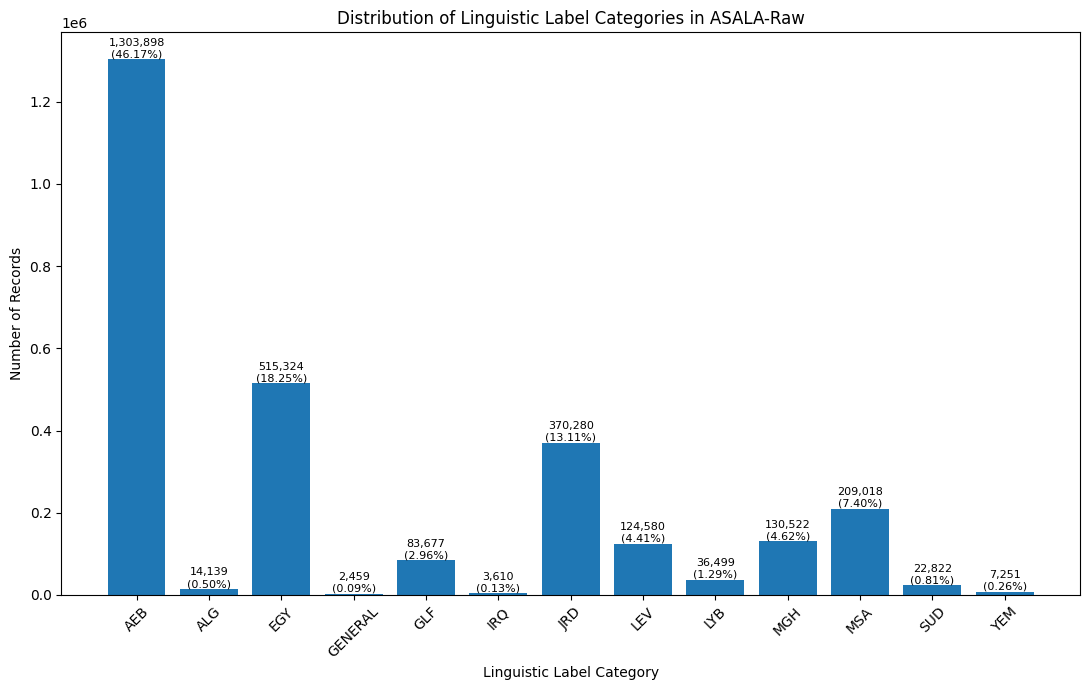

Processing AEB: 1,303,898 records...
Processing ALG: 14,139 records...
Processing EGY: 515,324 records...
Processing GENERAL: 2,459 records...
Processing GLF: 83,677 records...
Processing IRQ: 3,610 records...
Processing JRD: 370,280 records...
Processing LEV: 124,580 records...
Processing LYB: 36,499 records...
Processing MGH: 130,522 records...
Processing MSA: 209,018 records...
Processing SUD: 22,822 records...
Processing YEM: 7,251 records...

TABLE 4. LEXICAL DIVERSITY STATISTICS FOR FINAL ASALA-RAW
Dialect   Records Total Tokens Unique Tokens      TTR Shannon Entropy
    AEB 1,303,898  218,003,047     4,044,130 0.018551        12.62370
    ALG    14,139      313,935        76,584 0.243949        13.24242
    EGY   515,324    4,539,638       397,870 0.087644        13.10494
GENERAL     2,459       22,397        10,834 0.483725        12.02537
    GLF    83,677    1,225,328       198,237 0.161783        13.87675
    IRQ     3,610       44,908        13,529 0.301260        12.35778


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from math import log2


if "quality_df" not in globals():

    quality_df = df_dedup.copy()

    quality_df["Dialect"] = (
        quality_df["Dialect"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )


    quality_df = (
        quality_df
        .drop_duplicates(
            subset=[
                "normalized_text",
                "Dialect"
            ],
            keep="first"
        )
        .reset_index(drop=True)
    )



required_columns = [
    "Text",
    "Dialect"
]

missing_columns = [
    col for col in required_columns
    if col not in quality_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


N = len(quality_df)

print("=" * 70)
print("FINAL ASALA-RAW DESCRIPTIVE ANALYSIS")
print("=" * 70)

print(
    f"\nTotal records: {N:,}"
)

assert N == 2_824_079, (
    f"Expected 2,824,079 records, "
    f"but found {N:,}."
)



dialect_counts = (
    quality_df["Dialect"]
    .value_counts()
    .sort_index()
)

dialect_percentages = (
    dialect_counts
    / N
    * 100
)


distribution_table = pd.DataFrame({
    "Dialect": dialect_counts.index,
    "Records": dialect_counts.values,
    "Percentage": dialect_percentages.values
})


print("\n" + "=" * 70)
print("FINAL DIALECT DISTRIBUTION")
print("=" * 70)

distribution_print = distribution_table.copy()

distribution_print["Records"] = (
    distribution_print["Records"]
    .map(lambda x: f"{x:,}")
)

distribution_print["Percentage"] = (
    distribution_print["Percentage"]
    .map(lambda x: f"{x:.2f}%")
)

print(
    distribution_print.to_string(
        index=False
    )
)


print(
    "\nTotal records:",
    f"{dialect_counts.sum():,}"
)

print(
    "Total percentage:",
    f"{dialect_percentages.sum():.2f}%"
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.bar(
    distribution_table["Dialect"],
    distribution_table["Records"]
)

ax.set_title(
    "Distribution of Linguistic Label Categories in ASALA-Raw"
)

ax.set_xlabel(
    "Linguistic Label Category"
)

ax.set_ylabel(
    "Number of Records"
)

ax.tick_params(
    axis="x",
    rotation=45
)


# Add count + percentage above each bar
for bar, count, pct in zip(
    bars,
    distribution_table["Records"],
    distribution_table["Percentage"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=8
    )


plt.tight_layout()
plt.show()


def calculate_lexical_statistics(text_series):

    token_counter = Counter()

    total_tokens = 0

    for text in text_series:

        # Ignore missing text
        if pd.isna(text):
            continue

        # Whitespace tokenization
        tokens = str(text).split()

        if not tokens:
            continue

        token_counter.update(tokens)

        total_tokens += len(tokens)


    unique_tokens = len(token_counter)


    # Type-token ratio
    if total_tokens > 0:

        ttr = (
            unique_tokens
            / total_tokens
        )

    else:

        ttr = 0.0


    # Shannon entropy in bits
    if total_tokens > 0:

        entropy = -sum(
            (
                count / total_tokens
            )
            *
            log2(
                count / total_tokens
            )

            for count
            in token_counter.values()
        )

    else:

        entropy = 0.0


    return {
        "Total Tokens": total_tokens,
        "Unique Tokens": unique_tokens,
        "TTR": ttr,
        "Shannon Entropy": entropy
    }



table4_rows = []


for dialect in sorted(
    quality_df["Dialect"].unique()
):

    dialect_subset = (
        quality_df[
            quality_df["Dialect"] == dialect
        ]
    )

    record_count = len(
        dialect_subset
    )

    print(
        f"Processing {dialect}: "
        f"{record_count:,} records..."
    )


    lexical_stats = (
        calculate_lexical_statistics(
            dialect_subset["Text"]
        )
    )


    table4_rows.append({
        "Dialect": dialect,

        "Records":
            record_count,

        "Total Tokens":
            lexical_stats[
                "Total Tokens"
            ],

        "Unique Tokens":
            lexical_stats[
                "Unique Tokens"
            ],

        "TTR":
            lexical_stats[
                "TTR"
            ],

        "Shannon Entropy":
            lexical_stats[
                "Shannon Entropy"
            ]
    })


table4 = pd.DataFrame(
    table4_rows
)



assert (
    table4["Records"].sum()
    == N
), (
    "ERROR: Table 4 record counts "
    "do not match final dataset size."
)


table4_display = table4.copy()

table4_display["Records"] = (
    table4_display["Records"]
    .map(
        lambda x:
        f"{x:,}"
    )
)

table4_display["Total Tokens"] = (
    table4_display["Total Tokens"]
    .map(
        lambda x:
        f"{x:,}"
    )
)

table4_display["Unique Tokens"] = (
    table4_display["Unique Tokens"]
    .map(
        lambda x:
        f"{x:,}"
    )
)

table4_display["TTR"] = (
    table4_display["TTR"]
    .map(
        lambda x:
        f"{x:.6f}"
    )
)

table4_display["Shannon Entropy"] = (
    table4_display[
        "Shannon Entropy"
    ]
    .map(
        lambda x:
        f"{x:.5f}"
    )
)



print("\n" + "=" * 90)
print(
    "TABLE 4. LEXICAL DIVERSITY STATISTICS "
    "FOR FINAL ASALA-RAW"
)
print("=" * 90)

print(
    table4_display.to_string(
        index=False
    )
)


overall_stats = (
    calculate_lexical_statistics(
        quality_df["Text"]
    )
)


print("\n" + "=" * 70)
print("OVERALL ASALA-RAW LEXICAL SUMMARY")
print("=" * 70)

print(
    f"Records          : "
    f"{N:,}"
)

print(
    f"Total tokens     : "
    f"{overall_stats['Total Tokens']:,}"
)

print(
    f"Unique tokens    : "
    f"{overall_stats['Unique Tokens']:,}"
)

print(
    f"Overall TTR      : "
    f"{overall_stats['TTR']:.6f}"
)

print(
    f"Shannon entropy  : "
    f"{overall_stats['Shannon Entropy']:.5f}"
)


print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

In [ ]:
table4_manuscript = table4[
    [
        "Dialect",
        "Total Tokens",
        "Unique Tokens",
        "TTR",
        "Shannon Entropy"
    ]
].copy()


# Format values
table4_manuscript["Total Tokens"] = (
    table4_manuscript["Total Tokens"]
    .map(lambda x: f"{x:,}")
)

table4_manuscript["Unique Tokens"] = (
    table4_manuscript["Unique Tokens"]
    .map(lambda x: f"{x:,}")
)

table4_manuscript["TTR"] = (
    table4_manuscript["TTR"]
    .map(lambda x: f"{x:.6f}")
)

table4_manuscript["Shannon Entropy"] = (
    table4_manuscript["Shannon Entropy"]
    .map(lambda x: f"{x:.5f}")
)


print("\n" + "=" * 90)
print("TABLE 4. LEXICAL DIVERSITY STATISTICS FOR ASALA-RAW")
print("=" * 90)

print(
    table4_manuscript.to_string(
        index=False
    )
)


TABLE 4. LEXICAL DIVERSITY STATISTICS FOR ASALA-RAW
Dialect Total Tokens Unique Tokens      TTR Shannon Entropy
    AEB  218,003,047     4,044,130 0.018551        12.62370
    ALG      313,935        76,584 0.243949        13.24242
    EGY    4,539,638       397,870 0.087644        13.10494
GENERAL       22,397        10,834 0.483725        12.02537
    GLF    1,225,328       198,237 0.161783        13.87675
    IRQ       44,908        13,529 0.301260        12.35778
    JRD    5,028,253       564,140 0.112194        14.18760
    LEV    1,800,154       215,669 0.119806        13.32638
    LYB      513,908       113,887 0.221610        13.55576
    MGH    1,601,798       274,025 0.171073        14.01061
    MSA   15,295,850       949,058 0.062047        13.59296
    SUD      324,940        80,226 0.246895        13.17577
    YEM       99,681        21,319 0.213872        11.73882
